# Tech Challenge — Olist

## Pergunta norteadora

**O desempenho logístico impacta diretamente a satisfação dos clientes e o potencial de retenção e crescimento das operações de comércio eletrônico?**

Este projeto utiliza o Brazilian E-commerce Dataset disponibilizado pela Olist para analisar a relação entre eficiência logística, satisfação dos consumidores e indicadores de crescimento.

Ao longo do estudo são avaliados aspectos como tempo de aprovação dos pedidos, prazo de entrega, atrasos logísticos, avaliações dos clientes, retenção e evolução da receita, buscando identificar evidências de como a qualidade da operação logística pode influenciar a experiência do consumidor e a sustentabilidade do crescimento do negócio.

In [1]:
#Importando bibliotecas para análise

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Leitura dos arquivos

customers = pd.read_csv('olist_customers_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
geolocation = pd.read_csv('olist_geolocation_dataset.csv')
translation = pd.read_csv('product_category_name_translation.csv')

## **Análises iniciais**

### Análise inicial de dimensão dos datasets

Realizamos uma análise preliminar das dimensões das tabelas após a leitura dos dataframes. Utilizamos o método df.shape para obter o número de linhas e colunas de cada tabela. Como resultado, identificamos que a tabela de geolocalização possui mais de 1 milhão de registros. Esse dimensionamento será utilizado como base para a próxima etapa, onde iremos focar na limpeza e manipulação dessa tabela, a fim de garantir consistência e integridade dos dados para análises futuras.

In [3]:
datasets = {
    'customers': customers,
    'orders': orders,
    'items': items,
    'products': products,
    'reviews': reviews,
    'payments': payments,
    'sellers': sellers,
    'geolocation': geolocation,
    'translation': translation,
}

for nome, df in datasets.items():
    print(f'{nome:12s} -> {df.shape[0]:>9,} linhas | {df.shape[1]} colunas')


customers    ->    99,441 linhas | 5 colunas
orders       ->    99,441 linhas | 8 colunas
items        ->   112,650 linhas | 7 colunas
products     ->    32,951 linhas | 9 colunas
reviews      ->    99,224 linhas | 7 colunas
payments     ->   103,886 linhas | 5 colunas
sellers      ->     3,095 linhas | 4 colunas
geolocation  -> 1,000,163 linhas | 5 colunas
translation  ->        71 linhas | 2 colunas


### Verificação inicial de dados dos datasets

Realizamos uma leitura rápida (head) das principais tabelas (orders, customers, items, products) para entender a estrutura inicial dos dados, verificar o preenchimento das colunas e obter uma visão preliminar de como as informações estão organizadas.

Talvez utilizar df.info() para uma melhor visualização

In [4]:
# Visão geral rápida das principais tabelas

print('ORDERS')
display(orders.head())

print('CUSTOMERS')
display(customers.head())

print('ITEMS')
display(items.head())

print('PRODUCTS')
display(products.head())

ORDERS


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


CUSTOMERS


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


ITEMS


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


PRODUCTS


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


### Análise Preliminar das Tabelas
Nesta etapa, realizamos uma leitura rápida das tabelas principais para compreender a estrutura dos dados. Identificamos que algumas tabelas possuem valores nulos, especialmente nas colunas de datas e descrições. Além disso, na tabela de geolocalização, observamos um alto número de duplicatas, muitas vezes associadas ao mesmo CEP, mas com diferentes coordenadas. Esses pontos serão tratados de forma mais detalhada nas próximas etapas, durante o processo de limpeza e manipulação dos dados.

In [5]:
# Identificando valores nulos e duplicados nas bases

for nome, df in [('orders', orders), ('geolocation', geolocation), ('customers', customers), ('items', items), ('products', products), ('reviews', reviews), ('payments', payments), ('sellers', sellers)]:
    print(f'\n--- {nome.upper()} ---')
    print('Duplicados:', df.duplicated().sum())
    print(df.isnull().sum().sort_values(ascending=False).head(10))


--- ORDERS ---


Duplicados: 0
order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_id                            0
order_purchase_timestamp            0
order_status                        0
customer_id                         0
order_estimated_delivery_date       0
dtype: int64

--- GEOLOCATION ---


Duplicados: 261831
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

--- CUSTOMERS ---
Duplicados: 0
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

--- ITEMS ---


Duplicados: 0
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

--- PRODUCTS ---
Duplicados: 0
product_category_name         610
product_description_lenght    610
product_name_lenght           610
product_photos_qty            610
product_weight_g                2
product_height_cm               2
product_length_cm               2
product_width_cm                2
product_id                      0
dtype: int64

--- REVIEWS ---
Duplicados: 0
review_comment_title       87656
review_comment_message     58247
review_id                      0
review_score                   0
order_id                       0
review_creation_date           0
review_answer_timestamp        0
dtype: int64

--- PAYMENTS ---
Duplicados: 0
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int

In [6]:
# Validação dos tipos de dados das colunas em cada dataset

print("CUSTOMERS DTYPE:")
print(customers.dtypes, '\n')

print("ORDERS DTYPE:")
print(orders.dtypes, '\n')

print("ITEMS DTYPE:")
print(items.dtypes, '\n')

print("PRODUCTS DTYPE:")
print(products.dtypes, '\n')

print("REVIEWS DTYPE:")
print(reviews.dtypes, '\n')

print("PAYMENTS DTYPE:")
print(payments.dtypes, '\n')

print("SELLERS DTYPE:")
print(sellers.dtypes, '\n')

print("GEOLOCATION DTYPE:")
print(geolocation.dtypes, '\n')

print("TRANSLATION DTYPE:")
print(translation.dtypes, '\n')

CUSTOMERS DTYPE:
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object 

ORDERS DTYPE:
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object 

ITEMS DTYPE:
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object 

PRODUCTS DTYPE:
product_id                        str
product_category_name             str
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g   

### **Tratativa dos dataframes**

### Tratativa e Conversão de Tipos de Dados

Nesta etapa, realizamos uma série de conversões de tipos para garantir a consistência e preparar os dados para as análises. Os passos foram:

- **Conversão de Identificadores**: As colunas de identificadores (como `customer_id`, `product_id`, etc.) foram convertidas para o tipo string, garantindo que IDs sejam tratados como texto.

- **Conversão de Inteiros**: Campos que representam contagens ou medidas (como `product_name_lenght`, `product_description_lenght`, `product_photos_qty`) foram convertidos para inteiros, utilizando o tipo `int`, assegurando a precisão para análises numéricas.

- **Conversão de Datas**: As colunas que representam datas (`order_purchase_timestamp`, `order_approved_at`, etc.) foram convertidas para o tipo datetime, permitindo cálculos temporais e análises de sazonalidade.

- **Tratamento de Valores Nulos**: Identificamos colunas com valores nulos, especialmente em `product_category_name`. Para evitar a perda de dados, optamos por preencher essas categorias nulas com o valor "Desconhecida".

Ao final, estas conversões garantem que nossos dados estejam alinhados, prontos para as próximas etapas de análise, evitando erros e inconsistências em etapas subsequentes.

In [7]:
# Convertendo tipos de dados de cada coluna e tratando valores nulos e duplicados

#===========#
# CUSTOMERS #
#===========#
customers['customer_id'] = customers['customer_id'].astype(str)
customers['customer_unique_id'] = customers['customer_unique_id'].astype(str)
customers['customer_city'] = customers['customer_city'].astype(str)
customers['customer_state'] = customers['customer_state'].astype(str)

#========#
# ORDERS #
#========#
orders['order_id'] = orders['order_id'].astype(str)
orders['customer_id'] = orders['customer_id'].astype(str)
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

#=======#
# ITEMS #
#=======#
items['order_id'] = items['order_id'].astype(str)
items['order_item_id'] = items['order_item_id'].astype(int)
items['product_id'] = items['product_id'].astype(str)
items['shipping_limit_date'] = pd.to_datetime(items['shipping_limit_date'])
items['seller_id'] = items['seller_id'].astype(str)

#==========#
# PRODUCTS #
#==========#
products['product_id'] = products['product_id'].astype(str)
products['product_category_name'] = products['product_category_name'].fillna('Desconhecida').astype(str) # Preenche campos que possuem valores nulos com "Desconhecida"

####################

# Validação de impacto de substituir valores vazios na coluna "product_category_name" por "Desconhecida"

# Cria cópia do DataFrame original
products_original = products.copy()

# Cria cópia com 'Desconhecida'
products_desconhecida = products.copy()
products_desconhecida['product_category_name'] = (products_desconhecida['product_category_name'].fillna('Desconhecida'))

# Exemplo de agregação: total de vendas por categoria
vendas_original = products_original.merge(items, on='product_id', how='inner')
vendas_original = vendas_original.groupby('product_category_name').agg({'order_id': 'count', 'price': 'sum'}).reset_index()

vendas_desconhecida = products_desconhecida.merge(items, on='product_id', how='inner')
vendas_desconhecida = vendas_desconhecida.groupby('product_category_name').agg({'order_id': 'count', 'price': 'sum'}).reset_index()

# Comparação
print("Vendas original (com nulos):")
print(vendas_original)

print("Vendas com 'Desconhecida':")
print(vendas_desconhecida)

# Com as saídas deste trecho de código, não identificamos neste momento impactos negativos ou alterações significativas nas análises com a alteração

####################

products['product_name_lenght'] = products['product_name_lenght'].fillna(0).astype(int) # Utilizamos o fillna(0) para preencher campos nulos com 0
products['product_description_lenght'] = products['product_description_lenght'].fillna(0).astype(int)
products['product_photos_qty'] = products['product_photos_qty'].fillna(0).astype(int)
products['product_weight_g'] = products['product_weight_g'].fillna(0).astype(int)
products['product_length_cm'] = products['product_length_cm'].fillna(0).astype(int)
products['product_height_cm'] = products['product_height_cm'].fillna(0).astype(int)
products['product_width_cm'] = products['product_width_cm'].fillna(0).astype(int)

#=========#
# REVIEWS #
#=========#
reviews['review_id'] = reviews['review_id'].astype(str)
reviews['order_id'] = reviews['order_id'].astype(str)
reviews['review_comment_title'] = reviews['review_comment_title'].astype(str)
reviews['review_comment_message'] = reviews['review_comment_message'].astype(str)
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])

#==========#
# PAYMENTS #
#==========#
payments['order_id'] = payments['order_id'].astype(str)
payments['payment_type'] = payments['payment_type'].astype(str)

#=========#
# SELLERS #
#=========#
sellers['seller_id'] = sellers['seller_id'].astype(str)
sellers['seller_city'] = sellers['seller_city'].astype(str)
sellers['seller_state'] = sellers['seller_state'].astype(str)

#=============#
# GEOLOCATION #
#=============#
geolocation['geolocation_city'] = geolocation['geolocation_city'].astype(str)
geolocation['geolocation_state'] = geolocation['geolocation_state'].astype(str)

# Realizamos a agregação dos dados da tabela de geolocalização, agrupando os registros pelo prefixo do CEP.
# A análise inicial identificou uma quantidade excessiva de registros, pois cada variação mínima de latitude e longitude gerava múltiplas linhas para o mesmo CEP.
# Ao agrupar, calculamos a média das coordenadas (latitude e longitude) e mantivemos a cidade e o estado de referência.
# Testamos o impacto agregando os dados com e sem o agrupamento e confirmamos que as métricas, como total de vendas, se mantiveram estáveis.
# Dessa forma, a base resultante é mais leve, facilitando manipulações e análises subsequentes, sem impacto significativo nas conclusões.
geo_agrupada = (
    geolocation
    .groupby('geolocation_zip_code_prefix', as_index=False)
    .agg({
        'geolocation_lat': 'mean',
        'geolocation_lng': 'mean',
        'geolocation_city': 'first',
        'geolocation_state': 'first'
    })
)
print(geo_agrupada.head())

#=============#
# TRANSLATION #
#=============#
translation['product_category_name'] = translation['product_category_name'].astype(str)
translation['product_category_name_english'] = translation['product_category_name_english'].astype(str)


Vendas original (com nulos):
        product_category_name  order_id      price
0                Desconhecida      1603  179535.28
1   agro_industria_e_comercio       212   72530.47
2                   alimentos       510   29393.41
3           alimentos_bebidas       278   15179.48
4                       artes       209   24202.64
..                        ...       ...        ...
69    sinalizacao_e_seguranca       199   21509.23
70   tablets_impressao_imagem        83    7528.41
71                  telefonia      4545  323667.53
72             telefonia_fixa       264   59583.00
73      utilidades_domesticas      6964  632248.66

[74 rows x 3 columns]
Vendas com 'Desconhecida':
        product_category_name  order_id      price
0                Desconhecida      1603  179535.28
1   agro_industria_e_comercio       212   72530.47
2                   alimentos       510   29393.41
3           alimentos_bebidas       278   15179.48
4                       artes       209   24202.64
.. 

   geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
0                         1001       -23.550190       -46.634024   
1                         1002       -23.548146       -46.634979   
2                         1003       -23.548994       -46.635731   
3                         1004       -23.549799       -46.634757   
4                         1005       -23.549456       -46.636733   

  geolocation_city geolocation_state  
0        sao paulo                SP  
1        sao paulo                SP  
2        sao paulo                SP  
3        sao paulo                SP  
4        sao paulo                SP  


## Análise de Performance Logística

Após a etapa de tratamento e preparação dos dados, iniciamos a análise das métricas logísticas do marketplace.

O objetivo desta etapa é compreender o comportamento operacional dos pedidos ao longo do tempo, identificando padrões de aprovação, entrega e atrasos. Essas métricas são fundamentais para responder à pergunta norteadora do projeto, uma vez que a eficiência logística impacta diretamente a experiência do cliente e, consequentemente, sua satisfação.

Inicialmente serão analisadas três métricas principais:

- Tempo de aprovação do pedido;
- Tempo de entrega ao cliente;
- Dias de atraso em relação à data estimada.

Além da análise estatística, serão investigados possíveis valores extremos (outliers), buscando identificar se representam comportamentos reais do negócio ou inconsistências operacionais capazes de distorcer interpretações futuras.

In [8]:
# Tempo entre compra e aprovação

orders['tempo_aprovacao_horas'] = (
    orders['order_approved_at'] -
    orders['order_purchase_timestamp']
).dt.total_seconds() / 3600

# Tempo entre compra e entrega

orders['tempo_entrega_dias'] = (
    orders['order_delivered_customer_date'] -
    orders['order_purchase_timestamp']
).dt.days

# Diferença entre entrega real e estimada

orders['dias_atraso'] = (
    orders['order_delivered_customer_date'] -
    orders['order_estimated_delivery_date']
).dt.days

### Construção das Métricas Logísticas

Para avaliar a eficiência operacional dos pedidos, foram construídas métricas capazes de representar diferentes etapas da jornada logística.

O tempo de aprovação permite avaliar a agilidade inicial do processamento dos pedidos. O tempo de entrega representa o período total necessário para que o produto chegue ao consumidor. Já a métrica de dias de atraso permite medir o cumprimento do prazo prometido ao cliente.

Esses indicadores serão utilizados ao longo das análises para investigar possíveis impactos da operação logística na satisfação dos consumidores e nos resultados do negócio.

Análise do tempo de aprovação

In [9]:
orders['tempo_aprovacao_horas'].describe()

count    99281.000000
mean        10.419094
std         26.038004
min          0.000000
25%          0.215000
50%          0.343333
75%         14.580833
max       4509.180556
Name: tempo_aprovacao_horas, dtype: float64

In [10]:
orders[
    ['order_id', 'tempo_aprovacao_horas', 'order_status']
].sort_values('tempo_aprovacao_horas', ascending=False).head(30)

,order_id,tempo_aprovacao_horas,order_status
47552,1612081119e8f23745698ad3367cc14b,4509.180556,unavailable
62293,2e5dc86c8c4aa663549caf5e31de840d,1450.866389,processing
4541,2e7a8482f6fb09756ca50c10d7bfc047,784.045556,shipped
4396,e5fa5a7210941f7d56d0208e4e071d35,781.028056,canceled
43697,0a5c74ccc786ced7903270de9d6c170a,780.855000,unavailable
96251,0a93b40850d3f4becf2f276666e01340,741.443611,delivered
55708,f7923db0430587601c2aef15ec4b8af4,738.448889,delivered
53475,490291524fddde2b31c2e6bec3d9e6da,676.070000,canceled
10071,809a282bbd5dbcabb6f2f724fca862ec,573.874167,canceled
83143,fdd647b689626410b725d1cce2ddf37c,555.890278,processing


A análise do tempo de aprovação revelou que a maior parte dos pedidos é aprovada em poucas horas após a compra. Entretanto, foram identificados registros extremamente discrepantes, com tempos superiores a 200 horas e casos isolados acima de 4.500 horas.

Considerando que esses registros representam uma parcela extremamente reduzida da base e possuem potencial para distorcer médias e visualizações, optou-se por classificá-los como outliers operacionais e removê-los das análises subsequentes.

Essa decisão permite que os indicadores reflitam com maior precisão o comportamento predominante da operação.

Tempo de entrega

In [11]:
orders['tempo_entrega_dias'].describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: tempo_entrega_dias, dtype: float64

In [12]:
orders[
    ['order_id', 'tempo_entrega_dias', 'order_status']
].sort_values('tempo_entrega_dias', ascending=False).head(30)

,order_id,tempo_entrega_dias,order_status
19590,ca07593549f1816d26a572e06dc1eab6,209.0,delivered
55619,1b3190b2dfa9d789e1f14c05b647a14a,208.0,delivered
61610,440d0d17af552815d15a9e41abe49359,195.0,delivered
70307,2fb597c2f772eca01b1f5c561bf6cc7b,194.0,delivered
89130,285ab9426d6982034523a855f55a885e,194.0,delivered
38509,0f4519c5f1c541ddec9f21b3bddd533a,194.0,delivered
11399,47b40429ed8cce3aee9199792275433f,191.0,delivered
81401,2fe324febf907e3ea3f2aa9650869fa5,189.0,delivered
54480,2d7561026d542c8dbd8f0daeadf67a43,188.0,delivered
62286,437222e3fd1b07396f1d9ba8c15fba59,187.0,delivered


O tempo de entrega apresentou comportamento relativamente estável para a maior parte dos pedidos, concentrando-se próximo à mediana observada.

Entretanto, foram identificadas entregas superiores a 100 dias, incluindo casos acima de 200 dias. Embora representem ocorrências reais, esses registros constituem eventos excepcionais dentro da operação e possuem potencial para distorcer análises agregadas.

Dessa forma, optou-se por removê-los da análise principal, preservando o foco no comportamento predominante da experiência de entrega.

In [13]:
orders['dias_atraso'].describe()

count    96476.000000
mean       -11.876881
std         10.183854
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: dias_atraso, dtype: float64

In [14]:
orders[
    ['order_id', 'dias_atraso', 'order_status']
].sort_values('dias_atraso', ascending=False).head(30)

,order_id,dias_atraso,order_status
55619,1b3190b2dfa9d789e1f14c05b647a14a,188.0,delivered
19590,ca07593549f1816d26a572e06dc1eab6,181.0,delivered
11399,47b40429ed8cce3aee9199792275433f,175.0,delivered
81401,2fe324febf907e3ea3f2aa9650869fa5,167.0,delivered
89130,285ab9426d6982034523a855f55a885e,166.0,delivered
61610,440d0d17af552815d15a9e41abe49359,165.0,delivered
68769,c27815f7e3dd0b926b58552628481575,162.0,delivered
38509,0f4519c5f1c541ddec9f21b3bddd533a,161.0,delivered
40847,d24e8541128cea179a11a65176e0a96f,161.0,delivered
54480,2d7561026d542c8dbd8f0daeadf67a43,159.0,delivered


A análise dos dias de atraso demonstrou que a maioria dos pedidos foi entregue dentro do prazo previsto ou antecipadamente.

Apesar disso, foram identificados casos extremos com atrasos superiores a 100 dias. Por representarem ocorrências excepcionais e pouco representativas da operação como um todo, esses registros foram classificados como outliers.

A remoção desses casos permite uma avaliação mais consistente da capacidade logística da plataforma e de sua relação com a satisfação dos consumidores.

### Remoção de Outliers nas Métricas Logísticas

Após a análise das métricas de tempo de aprovação, tempo de entrega e dias de atraso, definimos que os outliers identificados não representam a realidade da maioria dos pedidos. A seguir, aplicamos a remoção dos registros extremos, garantindo que a análise subsequente seja focada na realidade predominante.

In [15]:
# Remoção de outliers no tempo de aprovação (acima de 200 horas)
orders = orders[orders['tempo_aprovacao_horas'] <= 200]

# Remoção de outliers no tempo de entrega (acima de 100 dias)
orders = orders[orders['tempo_entrega_dias'] <= 100]

# Remoção de outliers nos dias de atraso (acima de 100 dias)
orders = orders[orders['dias_atraso'] <= 100]

A remoção dos registros extremos resultou em uma base mais representativa do comportamento operacional predominante.

Embora esses casos possam possuir relevância para análises específicas de exceções logísticas, eles não representam o padrão observado na maior parte das transações.

Com a base ajustada, as análises seguintes passam a refletir com maior precisão a experiência típica dos consumidores, permitindo investigar de forma mais confiável a relação entre logística, satisfação e crescimento do negócio.

## KPIs Gerais do Negócio

Antes de aprofundar as análises específicas, é importante compreender a dimensão da operação analisada.

Os indicadores apresentados nesta seção fornecem uma visão consolidada do marketplace, incluindo volume de vendas, receita gerada, alcance geográfico, diversidade de produtos e satisfação dos consumidores.

Esses resultados servirão como referência para contextualizar as análises posteriores e compreender como os indicadores logísticos se relacionam com os resultados do negócio.

Receita geral com frete - tabela 'payments'

In [16]:
receita_total = (payments['payment_value']).sum()

print(f'Receita Total: R$ {receita_total:,.2f}')

Receita Total: R$ 16,008,872.12


In [17]:
total_pedidos = orders['order_id'].nunique()

ticket_medio = receita_total / total_pedidos

print(f"Receita Total: R$ {receita_total:,.2f}")
print(f"Ticket Médio: R$ {ticket_medio:,.2f}")

Receita Total: R$ 16,008,872.12
Ticket Médio: R$ 166.15


Clientes

In [18]:
clientes_unicos = customers['customer_unique_id'].nunique()

print(clientes_unicos)

96096


Total de pedidos


In [19]:
total_pedidos = orders['order_id'].nunique()

print(total_pedidos)

96353


Pedidos entregues

In [20]:
pedidos_entregues = (
    orders['order_status']
    .eq('delivered')
    .sum()
)

print(pedidos_entregues)

96347


Vendedores ativos

In [21]:
vendedores_ativos = sellers['seller_id'].nunique()

print(vendedores_ativos)

3095


Média de avaliações

In [22]:
nota_media = reviews['review_score'].mean()

print(f'Nota média: {nota_media:.2f}')

Nota média: 4.09


Tempo médio de entrega

In [23]:
tempo_medio_entrega = orders['tempo_entrega_dias'].mean()

print(tempo_medio_entrega)

12.004680705323135


Compliance

In [24]:
pedidos_entregues = orders[
    orders['order_status'] == 'delivered'
].copy()

compliance = (
    (pedidos_entregues['dias_atraso'] <= 0)
    .mean()
    * 100
)

entregues_no_prazo = (
    pedidos_entregues['dias_atraso'] <= 0
).sum()

entregues_atrasados = (
    pedidos_entregues['dias_atraso'] > 0
).sum()

print(f'Entregues no prazo: {entregues_no_prazo:,}')
print(f'Entregues atrasados: {entregues_atrasados:,}')
print(f'Compliance: {compliance:.2f}%')

Entregues no prazo: 89,884
Entregues atrasados: 6,463
Compliance: 93.29%


Categorias

In [25]:
categorias_ativas = (
    products['product_category_name']
    .nunique()
)

print(categorias_ativas)

74


Ticket médio

In [26]:
receita_total = items['price'].sum()

total_pedidos = orders['order_id'].nunique()

ticket_medio = receita_total / total_pedidos

print(f'Ticket Médio: R$ {ticket_medio:.2f}')

Ticket Médio: R$ 141.06


## Gráficos

Relação de receita total/pedidos por mês

In [27]:
receita_pedidos_mes = (
    items
    .merge(
        orders[['order_id', 'order_purchase_timestamp']],
        on='order_id',
        how='inner'
    )
)

receita_pedidos_mes['mes_ano'] = (
    receita_pedidos_mes['order_purchase_timestamp']
    .dt.to_period('M')
    .astype(str)
)

receita_pedidos_mes = (
    receita_pedidos_mes
    .groupby('mes_ano')
    .agg(
        receita_total=('price', 'sum'),
        quantidade_pedidos=('order_id', 'nunique')
    )
    .reset_index()
)

display(receita_pedidos_mes.head(20))

,mes_ano,receita_total,quantidade_pedidos
0,2016-09,134.97,1
1,2016-10,40941.30,270
2,2016-12,10.90,1
3,2017-01,111608.67,746
4,2017-02,231553.66,1634
5,2017-03,356921.73,2534
6,2017-04,339507.60,2294
7,2017-05,488013.73,3540
8,2017-06,421639.39,3132
9,2017-07,481604.52,3872


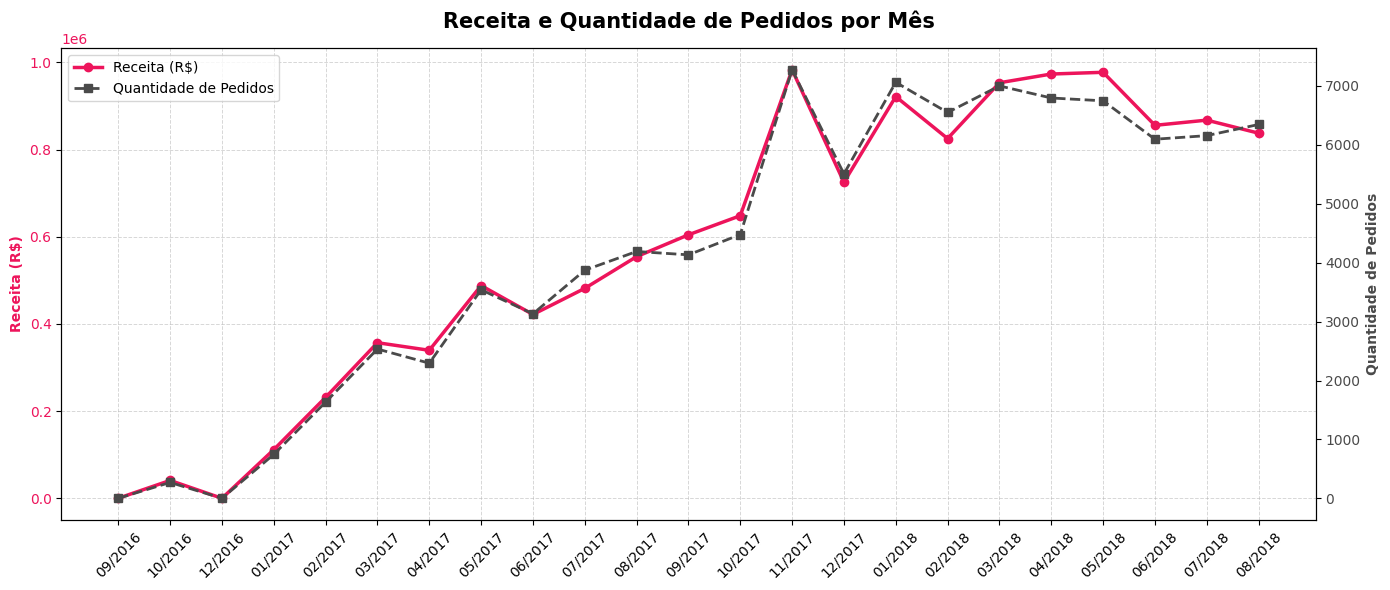

In [28]:
# Formata o eixo X para MM/AAAA
receita_pedidos_mes['mes_ano'] = pd.to_datetime(
    receita_pedidos_mes['mes_ano']
).dt.strftime('%m/%Y')

fig, ax1 = plt.subplots(figsize=(14,6))

# Receita
linha_receita = ax1.plot(
    receita_pedidos_mes['mes_ano'],
    receita_pedidos_mes['receita_total'],
    color='#ED145B',
    marker='o',
    linewidth=2.5,
    label='Receita (R$)'
)

ax1.set_ylabel(
    'Receita (R$)',
    color='#ED145B',
    fontweight='bold'
)

ax1.tick_params(
    axis='y',
    labelcolor='#ED145B'
)

# Grade horizontal e vertical
ax1.grid(
    True,
    axis='both',
    linestyle='--',
    linewidth=0.7,
    alpha=0.5
)

# Quantidade de pedidos
ax2 = ax1.twinx()

linha_pedidos = ax2.plot(
    receita_pedidos_mes['mes_ano'],
    receita_pedidos_mes['quantidade_pedidos'],
    color='#4A4A4A',
    marker='s',
    linestyle='--',
    linewidth=2,
    label='Quantidade de Pedidos'
)

ax2.set_ylabel(
    'Quantidade de Pedidos',
    color='#4A4A4A',
    fontweight='bold'
)

ax2.tick_params(
    axis='y',
    labelcolor='#4A4A4A'
)

# Título
plt.title(
    'Receita e Quantidade de Pedidos por Mês',
    fontsize=15,
    fontweight='bold',
    pad=15
)

# Datas na diagonal
ax1.tick_params(
    axis='x',
    rotation=45
)

# Legenda
linhas = linha_receita + linha_pedidos
labels = [linha.get_label() for linha in linhas]

ax1.legend(
    linhas,
    labels,
    loc='upper left',
    frameon=True
)

plt.tight_layout()
plt.show()

Partindo da nossa primeira hipótese, iremos identificar a quantidade de clientes únicos e recorrentes, a fim de elucidar melhor a taxa de recompra.

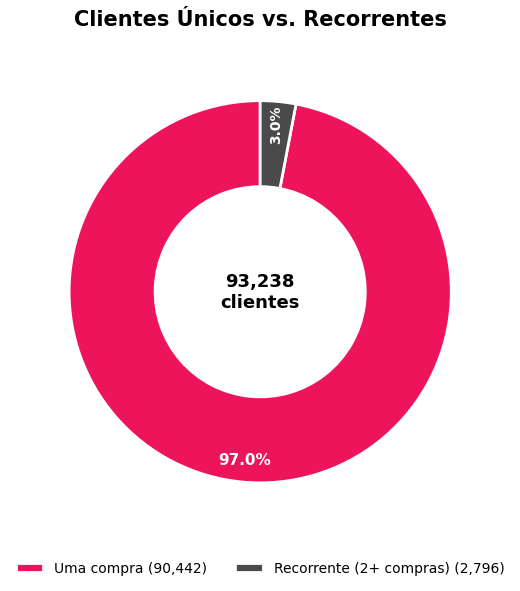

In [29]:
# Merge
df = orders.merge(
    customers,
    on='customer_id',
    how='left'
)

# Frequência de compras
frequencia_clientes = (
    df.groupby('customer_unique_id')['order_id']
      .count()
)

clientes_1_compra = (frequencia_clientes == 1).sum()
clientes_recompra = (frequencia_clientes >= 2).sum()

# Dados
dados = [clientes_1_compra, clientes_recompra]

labels = [
    f'Uma compra ({clientes_1_compra:,})',
    f'Recorrente (2+ compras) ({clientes_recompra:,})'
]


cores = ['#ED145B', '#4A4A4A']

# Total
total = sum(dados)

fig, ax = plt.subplots(figsize=(8, 6))

# Gráfico de rosca
wedges, texts, autotexts = ax.pie(
    dados,
    colors=cores,
    startangle=90,
    autopct='%1.1f%%',
    pctdistance=0.88,
    wedgeprops=dict(
        width=0.45,
        edgecolor='white',
        linewidth=2
    )
)

# Estilo dos percentuais
menor_fatia = dados.index(min(dados))

for i, autotext in enumerate(autotexts):
    autotext.set_color('white')
    autotext.set_fontweight('bold')

    if i == menor_fatia:
        autotext.set_rotation(90)
        autotext.set_fontsize(10)
        autotext.set_va('center')
        autotext.set_ha('center')
    else:
        autotext.set_fontsize(11)

# Texto central
ax.text(
    0,
    0,
    f'{total:,}\nclientes',
    ha='center',
    va='center',
    fontsize=13,
    fontweight='bold'
)

# Título
plt.title(
    'Clientes Únicos vs. Recorrentes',
    fontsize=15,
    fontweight='bold',
    pad=20
)

# Legenda
plt.legend(
    wedges,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False
)

plt.tight_layout()
plt.show()

### Recompra é explicada pela logística?

O gráfico anterior evidencia que a recompra é baixa na base como um todo. A hipótese natural, dado o que já vimos sobre o impacto da logística na satisfação, é que pedidos com atraso levem a uma recompra ainda menor.

Para não tratar essa hipótese como verdade apenas por parecer razoável, o próximo passo é testá-la diretamente: comparar a taxa de recompra entre clientes cuja primeira compra chegou no prazo e clientes cuja primeira compra chegou atrasada, e validar estatisticamente se a diferença observada é relevante ou se pode ser apenas variação aleatória da amostra.

In [30]:
# Identifica a primeira compra de cada cliente (já temos 'df' e 'frequencia_clientes' da etapa anterior)
df_ordenado = df.sort_values(['customer_unique_id', 'order_purchase_timestamp'])
primeira_compra = df_ordenado.groupby('customer_unique_id').first().reset_index()

# Marca se o cliente recomprou, usando a mesma contagem já calculada no gráfico anterior
clientes_recompra_set = set(frequencia_clientes[frequencia_clientes >= 2].index)
primeira_compra['recomprou'] = primeira_compra['customer_unique_id'].isin(clientes_recompra_set)

# Faixas de atraso da primeira compra (mesmos cortes usados na análise de entrega x satisfação)
primeira_compra_atraso = primeira_compra.dropna(subset=['dias_atraso']).copy()

primeira_compra_atraso['faixa_atraso'] = pd.cut(
    primeira_compra_atraso['dias_atraso'],
    bins=[-999, 0, 5, 15, 999],
    labels=[
        'No prazo',
        'Até 5 dias',
        '6 a 15 dias',
        'Mais de 15 dias'
    ]
)

# Taxa de recompra por faixa de atraso
recompra_x_atraso = (
    primeira_compra_atraso
    .groupby('faixa_atraso', observed=False)
    .agg(
        clientes=('customer_unique_id', 'count'),
        recompraram=('recomprou', 'sum')
    )
    .reset_index()
)
recompra_x_atraso['taxa_recompra_pct'] = (
    recompra_x_atraso['recompraram'] / recompra_x_atraso['clientes'] * 100
).round(2)

display(recompra_x_atraso)

,faixa_atraso,clientes,recompraram,taxa_recompra_pct
0,No prazo,86951,2634,3.03
1,Até 5 dias,2695,66,2.45
2,6 a 15 dias,2466,64,2.60
3,Mais de 15 dias,1126,32,2.84


In [31]:
from scipy.stats import chi2_contingency

# Teste qui-quadrado de independência: a faixa de atraso da 1ª compra influencia a recompra?
tabela_contingencia = pd.crosstab(
    primeira_compra_atraso['faixa_atraso'],
    primeira_compra_atraso['recomprou']
)

chi2, p_valor, graus_liberdade, esperado = chi2_contingency(tabela_contingencia)

print(f'Chi² = {chi2:.2f}')
print(f'p-valor = {p_valor:.4f}')
print(f'Graus de liberdade = {graus_liberdade}')

if p_valor < 0.05:
    print('\nResultado: existe associação estatisticamente significativa entre atraso e recompra.')
else:
    print('\nResultado: NÃO há evidência estatística de associação entre atraso e recompra (p >= 0.05).')

Chi² = 4.55
p-valor = 0.2075
Graus de liberdade = 3

Resultado: NÃO há evidência estatística de associação entre atraso e recompra (p >= 0.05).


O teste qui-quadrado retorna um p-valor acima de 0,05, ou seja, **não há evidência estatística de que o atraso na primeira compra influencie a decisão do cliente de recomprar**. A taxa de recompra permanece próxima de 3% independentemente de o cliente ter recebido o pedido no prazo ou com atraso.

Isso não invalida a relação já demonstrada entre atraso e satisfação (queda na nota de avaliação) — essa relação continua sólida e foi comprovada diretamente nos gráficos anteriores. O que o teste mostra é que a ponte entre "menor satisfação" e "menor recompra" não pode ser assumida apenas por inferência; precisa ser testada, e neste caso específico ela não se confirma.

Diante disso, vale investigar se existem outras variáveis que expliquem melhor a baixa recompra observada — começando pela categoria do produto comprado e pelo valor da primeira compra.

In [32]:
# Recompra por categoria de produto da primeira compra
primeira_compra_categoria = (
    items
    .merge(
        primeira_compra[['order_id', 'customer_unique_id', 'recomprou']],
        on='order_id',
        how='inner'
    )
    .sort_values('order_id')
    .drop_duplicates(subset='order_id', keep='first')
    .merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
    .merge(translation, on='product_category_name', how='left')
)

recompra_x_categoria = (
    primeira_compra_categoria
    .groupby('product_category_name_english')['recomprou']
    .agg(clientes='count', recompraram='sum')
    .reset_index()
)
recompra_x_categoria['taxa_recompra_pct'] = (
    recompra_x_categoria['recompraram'] / recompra_x_categoria['clientes'] * 100
).round(2)

# Mantém apenas categorias com volume mínimo para a comparação ser representativa
recompra_x_categoria = recompra_x_categoria[recompra_x_categoria['clientes'] >= 300]

top5_categorias = recompra_x_categoria.sort_values('taxa_recompra_pct', ascending=False).head(5)
bottom5_categorias = recompra_x_categoria.sort_values('taxa_recompra_pct', ascending=True).head(5)

top_bottom_categoria = pd.concat([bottom5_categorias, top5_categorias]).sort_values('taxa_recompra_pct')

display(top_bottom_categoria)

,product_category_name_english,clientes,recompraram,taxa_recompra_pct
26,electronics,2460,40,1.63
56,musical_instruments,595,10,1.68
16,consoles_games,996,18,1.81
20,cool_stuff,3461,65,1.88
17,construction_tools_construction,708,14,1.98
7,bed_bath_table,8714,383,4.40
47,home_confort,356,16,4.49
39,furniture_decor,5904,270,4.57
28,fashion_bags_accessories,1690,97,5.74
44,home_appliances,677,61,9.01


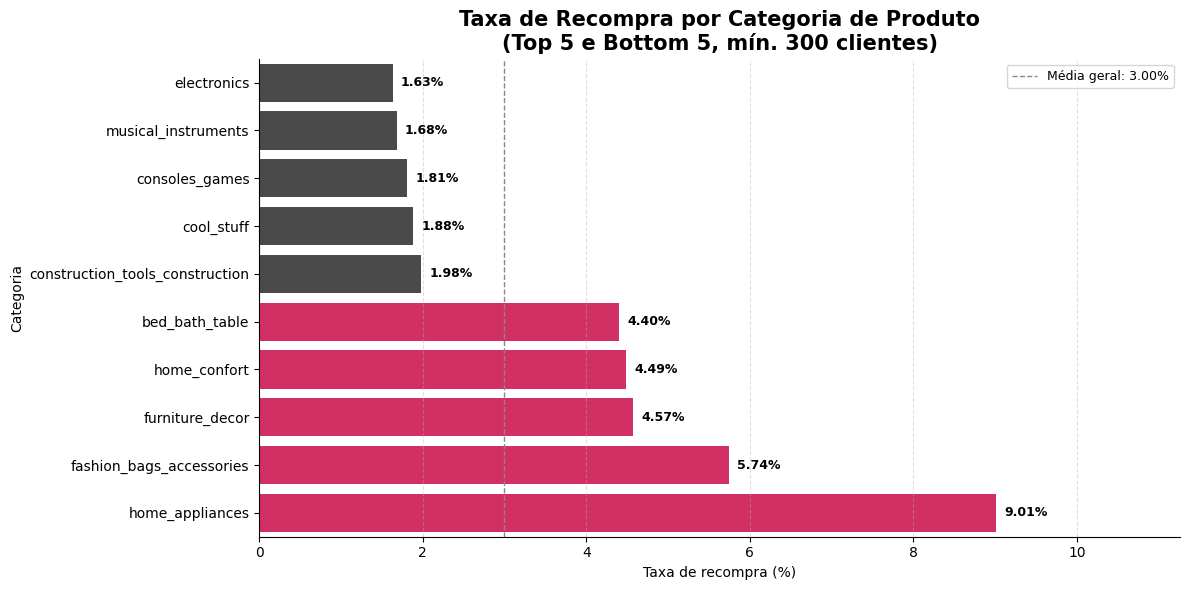

In [33]:
media_recompra_geral = (frequencia_clientes >= 2).mean() * 100

cores = [
    '#4A4A4A' if valor < media_recompra_geral
    else '#ED145B'
    for valor in top_bottom_categoria['taxa_recompra_pct']
]

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=top_bottom_categoria,
    x='taxa_recompra_pct',
    y='product_category_name_english',
    palette=cores,
    hue='product_category_name_english',
    legend=False,
    ax=ax
)

for i, valor in enumerate(top_bottom_categoria['taxa_recompra_pct']):
    ax.text(
        valor + 0.1,
        i,
        f'{valor:.2f}%',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

ax.axvline(
    media_recompra_geral,
    color='#888888',
    linestyle='--',
    linewidth=1,
    label=f'Média geral: {media_recompra_geral:.2f}%'
)
ax.legend(loc='upper right', frameon=True, fontsize=9)

ax.set_title(
    'Taxa de Recompra por Categoria de Produto\n(Top 5 e Bottom 5, mín. 300 clientes)',
    fontsize=15,
    fontweight='bold'
)
ax.set_xlabel('Taxa de recompra (%)')
ax.set_ylabel('Categoria')
ax.set_xlim(0, top_bottom_categoria['taxa_recompra_pct'].max() * 1.25)

ax.grid(axis='x', linestyle='--', alpha=0.4)
sns.despine(left=False, bottom=False)

plt.tight_layout()
plt.show()

A categoria de produto mostra uma diferença expressiva: eletrodomésticos e bolsas/acessórios recompram bem acima da média da base, enquanto eletrônicos e consoles de videogame recompram bem abaixo. Essa diferença é estatisticamente significativa e muito mais forte do que a observada para atraso de entrega.

Outra variável com potencial de explicar a recompra é o valor da primeira compra: clientes que gastam mais podem ter um padrão de recorrência diferente de clientes que compram itens de baixo valor.

In [34]:
# Recompra por faixa de valor (ticket) da primeira compra
valor_pedido = items.groupby('order_id')['price'].sum().reset_index()

primeira_compra_ticket = primeira_compra.merge(valor_pedido, on='order_id', how='inner')

primeira_compra_ticket['faixa_ticket'] = pd.cut(
    primeira_compra_ticket['price'],
    bins=[0, 50, 100, 200, 500, 1_000_000],
    labels=['Até R$50', 'R$50-100', 'R$100-200', 'R$200-500', 'R$500+']
)

recompra_x_ticket = (
    primeira_compra_ticket
    .groupby('faixa_ticket', observed=True)['recomprou']
    .agg(clientes='count', recompraram='sum')
    .reset_index()
)
recompra_x_ticket['taxa_recompra_pct'] = (
    recompra_x_ticket['recompraram'] / recompra_x_ticket['clientes'] * 100
).round(2)

display(recompra_x_ticket)

# Teste qui-quadrado: a faixa de ticket influencia a recompra?
tabela_ticket = pd.crosstab(
    primeira_compra_ticket['faixa_ticket'],
    primeira_compra_ticket['recomprou']
)
chi2_ticket, p_ticket, dof_ticket, esp_ticket = chi2_contingency(tabela_ticket)

print(f'\nChi² = {chi2_ticket:.2f}')
print(f'p-valor = {p_ticket:.6f}')

,faixa_ticket,clientes,recompraram,taxa_recompra_pct
0,Até R$50,28027,892,3.18
1,R$50-100,26667,846,3.17
2,R$100-200,24473,689,2.82
3,R$200-500,10682,302,2.83
4,R$500+,3389,67,1.98



Chi² = 22.10
p-valor = 0.000192


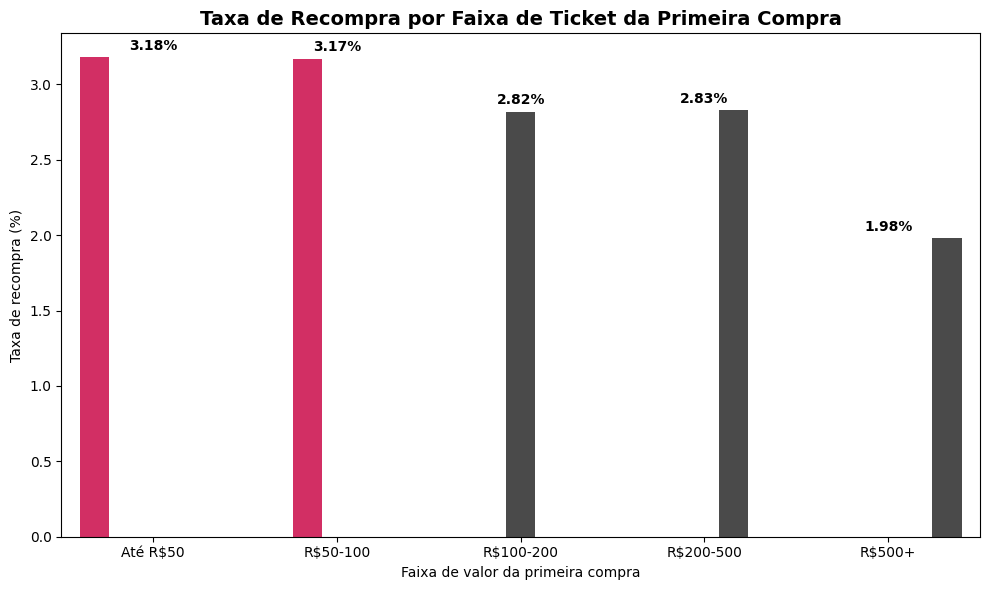

In [35]:
cores = [
    '#ED145B' if valor >= media_recompra_geral
    else '#4A4A4A'
    for valor in recompra_x_ticket['taxa_recompra_pct']
]

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=recompra_x_ticket,
    x='faixa_ticket',
    y='taxa_recompra_pct',
    palette=cores,
    hue='faixa_ticket',
    legend=False,
    ax=ax
)

for i, valor in enumerate(recompra_x_ticket['taxa_recompra_pct']):
    ax.text(
        i,
        valor + 0.05,
        f'{valor:.2f}%',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

ax.set_title(
    'Taxa de Recompra por Faixa de Ticket da Primeira Compra',
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel('Faixa de valor da primeira compra')
ax.set_ylabel('Taxa de recompra (%)')

plt.tight_layout()
plt.show()

O teste estatístico confirma que a faixa de ticket também está associada à recompra (p < 0,05), com destaque para a queda na faixa acima de R$ 500. Combinado com o resultado de categoria, isso indica que **o perfil do produto comprado explica melhor a recompra do que o desempenho logístico** nesta base de dados.

Essa conclusão é importante para a etapa final do projeto: as recomendações de retenção devem considerar categoria e ticket como variáveis de segmentação, e não tratar a melhoria logística como a única (ou principal) alavanca para aumentar a recompra.

### Relação entre Tempo de Entrega e Satisfação dos Clientes

Após compreender o comportamento logístico da operação, o próximo passo consiste em investigar se o prazo necessário para concluir uma entrega influencia a percepção dos consumidores.

Para isso, os pedidos foram agrupados em faixas de tempo de entrega e comparados com suas respectivas avaliações médias.

In [36]:
kpi_entrega_satisfacao = (
    orders[['order_id', 'tempo_entrega_dias']]
    .merge(
        reviews[['order_id', 'review_score']],
        on='order_id',
        how='inner'
    )
)

# Cria faixas de entrega

kpi_entrega_satisfacao['faixa_entrega'] = pd.cut(
    kpi_entrega_satisfacao['tempo_entrega_dias'],
    bins=[0, 5, 10, 15, 20, 999],
    labels=[
        'Até 5 dias',
        '6 a 10 dias',
        '11 a 15 dias',
        '16 a 20 dias',
        'Mais de 20 dias'
    ]
)

# Calcula avaliação média por faixa

kpi_entrega_satisfacao = (
    kpi_entrega_satisfacao
    .groupby('faixa_entrega', observed=False)
    .agg(
        review_medio=('review_score', 'mean'),
        total_pedidos=('order_id', 'count')
    )
    .reset_index()
)

display(kpi_entrega_satisfacao)

,faixa_entrega,review_medio,total_pedidos
0,Até 5 dias,4.431055,19211
1,6 a 10 dias,4.347767,32841
2,11 a 15 dias,4.245414,21152
3,16 a 20 dias,4.091699,10709
4,Mais de 20 dias,3.122066,12313


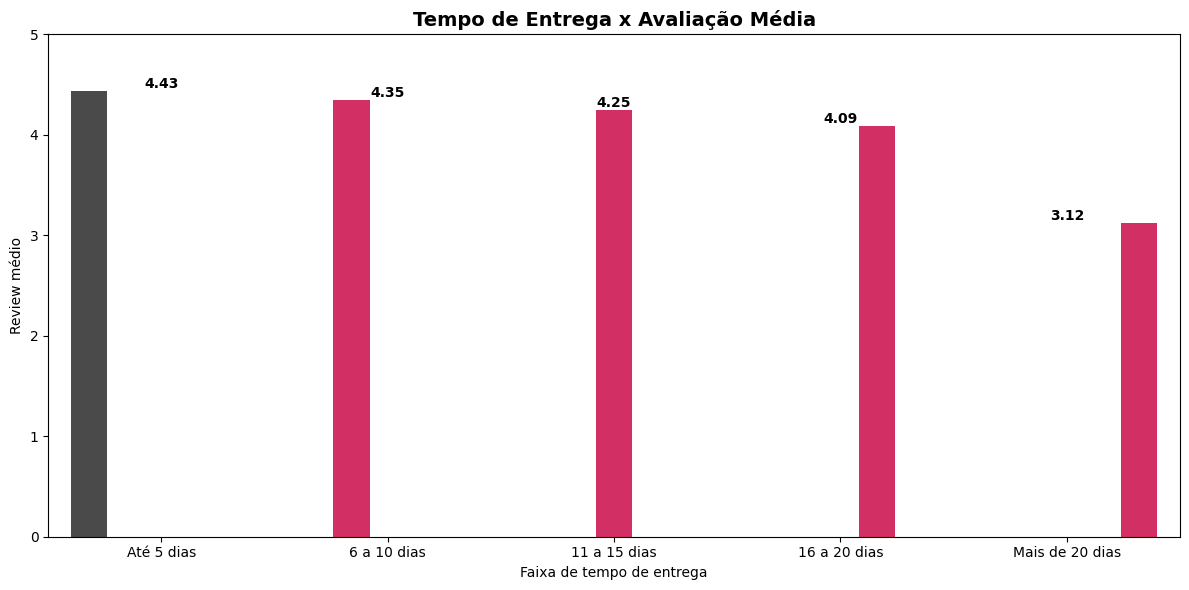

In [37]:
cores = [
    '#4A4A4A',
    '#ED145B',
    '#ED145B',
    '#ED145B',
    '#ED145B'
]

fig, ax = plt.subplots(figsize=(12,6))

sns.barplot(
    data=kpi_entrega_satisfacao,
    x='faixa_entrega',
    y='review_medio',
    hue='faixa_entrega',
    palette=cores,
    legend=False,
    ax=ax
)

for i, valor in enumerate(kpi_entrega_satisfacao['review_medio']):
    ax.text(
        i,
        valor + 0.03,
        f'{valor:.2f}',
        ha='center',
        fontweight='bold'
    )

ax.set_title(
    'Tempo de Entrega x Avaliação Média',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('Faixa de tempo de entrega')
ax.set_ylabel('Review médio')
ax.set_ylim(0,5)

plt.tight_layout()
plt.show()

### Relação entre Notas e atraso na entrega dos pedidos

Em seguida, para validação do cenário proposto, verificaremos a relação entre o atraso no prazo de entrega e as avaliações

In [38]:
# Junta pedidos e avaliações

satisfacao_logistica = (
    orders[
        [
            'order_id',
            'dias_atraso'
        ]
    ]
    .merge(
        reviews[
            [
                'order_id',
                'review_score'
            ]
        ],
        on='order_id',
        how='inner'
    )
)

# Criação das faixas de atraso

satisfacao_logistica['cenario'] = pd.cut(
    satisfacao_logistica['dias_atraso'],
    bins=[-999, 0, 5, 15, 999],
    labels=[
        'No prazo',
        'Até 5 dias',
        '6 a 15 dias',
        'Mais de 15 dias'
    ]
)

# KPI de satisfação

kpi_satisfacao = (
    satisfacao_logistica
    .groupby('cenario', observed=False)
    .agg(
        review_medio=('review_score', 'mean'),
        total_pedidos=('order_id', 'count')
    )
    .reset_index()
)

display(kpi_satisfacao)

,cenario,review_medio,total_pedidos
0,No prazo,4.29001,89897
1,Até 5 dias,2.98862,2724
2,6 a 15 dias,1.74498,2490
3,Mais de 15 dias,1.66578,1128


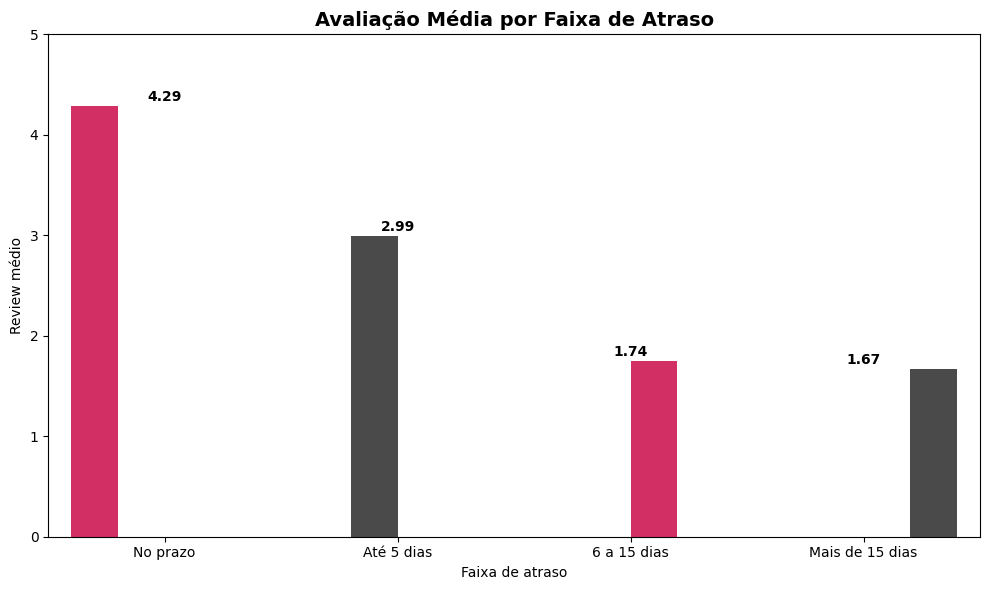

In [39]:
cores = ['#ED145B', '#4A4A4A']

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=kpi_satisfacao,
    x='cenario',
    y='review_medio',
    hue='cenario',
    palette=cores * 2,  # repete as cores
    legend=False,
    ax=ax
)

for i, valor in enumerate(kpi_satisfacao['review_medio']):
    ax.text(
        i,
        valor + 0.05,
        f'{valor:.2f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

ax.set_title(
    'Avaliação Média por Faixa de Atraso',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('Faixa de atraso')
ax.set_ylabel('Review médio')
ax.set_ylim(0, 5)

plt.tight_layout()
plt.show()

### Receita mensal por região



/tmp/ipykernel_834/406733965.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


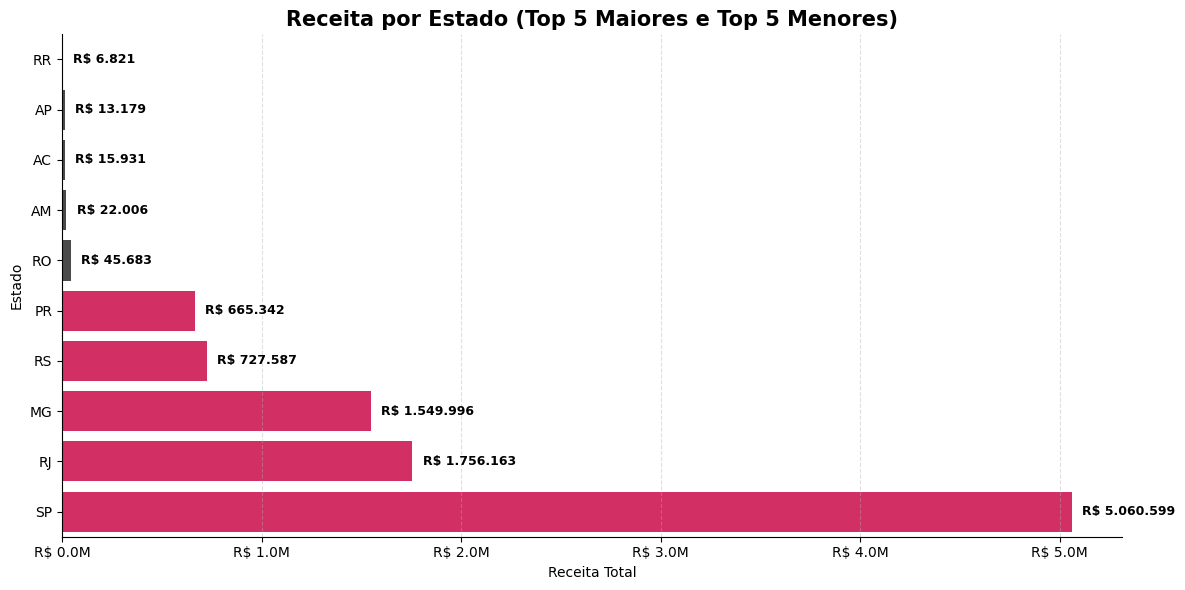

In [40]:
from matplotlib.ticker import FuncFormatter

# Receita por estado
receita_estado = (
    orders
    .merge(customers, on='customer_id')
    .merge(items[['order_id', 'price']], on='order_id')
)

receita_estado = (
    receita_estado
    .query("order_status == 'delivered'")
    .groupby('customer_state')['price']
    .sum()
    .reset_index()
)

# Top 5 maiores
top5 = (
    receita_estado
    .sort_values('price', ascending=False)
    .head(5)
)

# Top 5 menores
bottom5 = (
    receita_estado
    .sort_values('price', ascending=True)
    .head(5)
)

# Adiciona categoria
top5['grupo'] = 'Top 5'
bottom5['grupo'] = 'Bottom 5'

# Junta
top_bottom = pd.concat([top5, bottom5])

# Ordena para visualização
top_bottom = top_bottom.sort_values('price')

# Define cores fixas
cores = [
    '#4A4A4A' if grupo == 'Bottom 5'
    else '#ED145B'
    for grupo in top_bottom['grupo']
]

# Gráfico
fig, ax = plt.subplots(figsize=(12,6))

sns.barplot(
    data=top_bottom,
    x='price',
    y='customer_state',
    palette=cores,
    ax=ax
)

# Remove notação científica
ax.ticklabel_format(style='plain', axis='x')

# Formata eixo em milhões
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'R$ {x/1_000_000:.1f}M')
)

# Valores sobre as barras
for i, valor in enumerate(top_bottom['price']):
    ax.text(
        valor + (top_bottom['price'].max() * 0.01),
        i,
        f'R$ {valor:,.0f}'.replace(',', '.'),
        va='center',
        fontsize=9,
        fontweight='bold'
    )

ax.set_title(
    'Receita por Estado (Top 5 Maiores e Top 5 Menores)',
    fontsize=15,
    fontweight='bold'
)

ax.set_xlabel('Receita Total')
ax.set_ylabel('Estado')

ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

sns.despine(
    left=False,
    bottom=False
)

plt.tight_layout()
plt.show()

Quantidade de pedidos por região

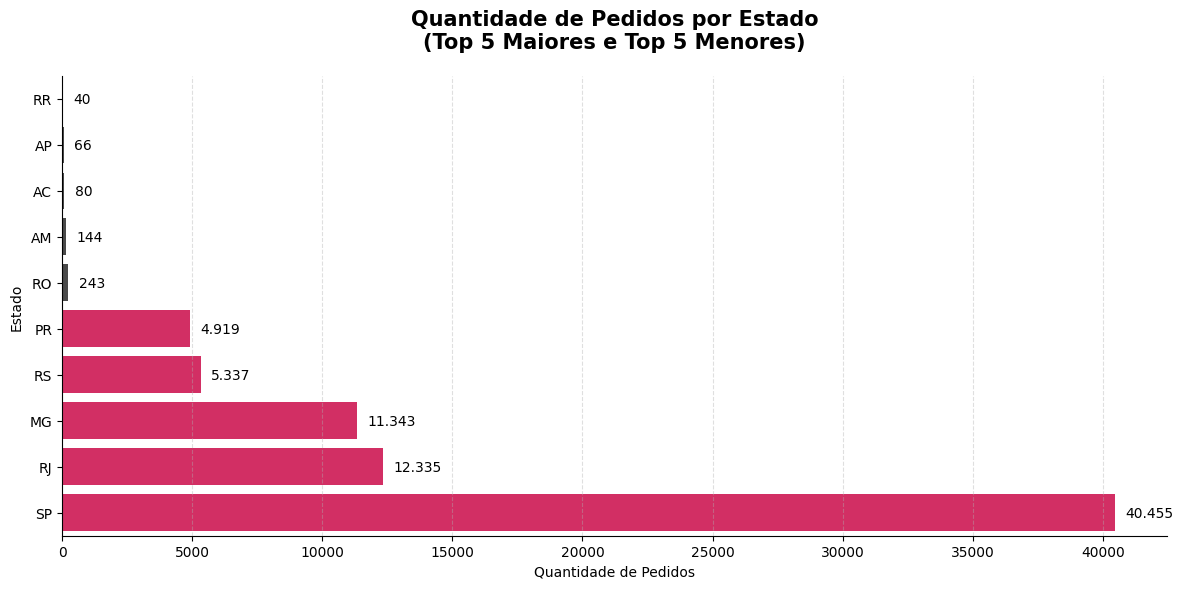

In [41]:
# Quantidade de pedidos por estado

pedidos_estado = (
    orders
    .merge(customers, on='customer_id')
    .query("order_status == 'delivered'")
    .groupby('customer_state')['order_id']
    .nunique()
    .reset_index(name='quantidade_pedidos')
)

# Top 5 maiores
top5 = (
    pedidos_estado
    .sort_values('quantidade_pedidos', ascending=False)
    .head(5)
)

# Top 5 menores
bottom5 = (
    pedidos_estado
    .sort_values('quantidade_pedidos', ascending=True)
    .head(5)
)

# Junta os grupos
top_bottom = pd.concat([top5, bottom5])

# Ordena para visualização
top_bottom = top_bottom.sort_values('quantidade_pedidos')

# Cores
cores = [
    '#4A4A4A' if x < top_bottom['quantidade_pedidos'].median()
    else '#ED145B'
    for x in top_bottom['quantidade_pedidos']
]

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_bottom,
    x='quantidade_pedidos',
    y='customer_state',
    palette=cores,
    hue='customer_state',
    legend=False
)

# Valores nas barras
for i, valor in enumerate(top_bottom['quantidade_pedidos']):
    ax.text(
        valor + (top_bottom['quantidade_pedidos'].max() * 0.01),
        i,
        f'{valor:,.0f}'.replace(',', '.'),
        va='center',
        fontsize=10
    )

plt.title(
    'Quantidade de Pedidos por Estado\n(Top 5 Maiores e Top 5 Menores)',
    fontsize=15,
    fontweight='bold',
    pad=20
)

plt.xlabel('Quantidade de Pedidos')
plt.ylabel('Estado')

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

# Remove molduras superiores e direitas
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

In [42]:
# Cria coluna de ano
orders['ano'] = orders['order_purchase_timestamp'].dt.year

# Base de receita
receita_pedido = (
    orders
    .merge(items[['order_id', 'price']], on='order_id')
    .query("order_status == 'delivered'")
)

# KPIs anuais
kpi_anual = (
    receita_pedido
    .groupby('ano')
    .agg(
        receita_total=('price', 'sum'),
        quantidade_pedidos=('order_id', 'nunique')
    )
    .reset_index()
)

# Receita em milhões
kpi_anual['receita_milhoes'] = (
    kpi_anual['receita_total'] / 1_000_000
).round(2)

# Formatação para exibição
kpi_anual['receita_total'] = (
    kpi_anual['receita_total']
    .map(lambda x: f'R$ {x:,.2f}')
    .str.replace(',', 'X')
    .str.replace('.', ',')
    .str.replace('X', '.')
)

display(
    kpi_anual[
        [
            'ano',
            'quantidade_pedidos',
            'receita_total',
            'receita_milhoes'
        ]
    ]
)

,ano,quantidade_pedidos,receita_total,receita_milhoes
0,2016,267,"R$ 40.470,98",0.04
1,2017,43333,"R$ 5.945.913,60",5.95
2,2018,52747,"R$ 7.210.957,61",7.21


## Resposta à Pergunta Norteadora

Os resultados obtidos confirmam parcialmente a hipótese inicial: o desempenho logístico possui relação direta e comprovada com a satisfação dos consumidores, mas não se confirma como o principal fator por trás da baixa recompra observada na base.

**Logística → Satisfação: confirmado.** Pedidos entregues com maior atraso apresentaram avaliações consistentemente inferiores, tanto na análise por faixa de tempo de entrega quanto na análise por faixa de atraso. Essa relação é clara e se mantém em toda a base de dados.

**Logística → Recompra: não confirmado estatisticamente.** Ao testar diretamente se a faixa de atraso da primeira compra influencia a decisão do cliente de recomprar, o teste qui-quadrado não encontrou associação estatisticamente significativa (p ≈ 0,21). A taxa de recompra permanece próxima de 3% independentemente de o cliente ter recebido o pedido no prazo ou com atraso.

**O que de fato está associado à recompra:** a categoria do produto e o valor da primeira compra mostraram associação estatisticamente significativa com a recompra (p < 0,001 e p < 0,05, respectivamente). Categorias como eletrodomésticos e bolsas/acessórios recompram bem acima da média da base, enquanto eletrônicos, consoles de videogame e compras acima de R$ 500 recompram bem abaixo.

**Conclusão:** a logística é, sim, um fator estratégico — mas para a satisfação do cliente e para a reputação da operação, não como explicação direta da baixa recompra. Iniciativas de retenção têm mais chance de sucesso se forem segmentadas por categoria de produto e faixa de ticket do que se dependerem apenas de melhorias no prazo de entrega. Isso não reduz a relevância de investir em logística — apenas evita atribuir a ela um efeito que os dados não sustentam.

## Exportação de datframes tratatos

In [43]:
# Exporta tabelas novas com alterações
customers.to_csv('customers.csv', index=False)
orders.to_csv('orders.csv', index=False)
items.to_csv('items.csv', index=False)
products.to_csv('products.csv', index=False)
reviews.to_csv('reviews.csv', index=False)
payments.to_csv('payments.csv', index=False)
sellers.to_csv('sellers.csv', index=False)

# Geolocalização tratada
geo_agrupada.to_csv('geolocation.csv', index=False)

translation.to_csv('translation.csv', index=False)

print('Exportação concluída.')

Exportação concluída.
